See coresp. notebook for shendure for explanation.

In [39]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
from pathlib import Path
import numpy as np
import uuid
import pandas as pd

In [40]:
data_root=Path("/nfs/roberts/project/pi_skr2/shared/tabula_data")

In [41]:
local=False
if local:
    cluster=LocalCluster(memory_limit='48G')
    client=Client(cluster)
else:
    cluster=SLURMCluster(
        cores=3,#cores per slurm job
        memory="32G",#memory per slurm job
        processes=1,#dask workers per slurm job,
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=2:00:00",
            f"--output=worker_%j.out"]
    )
    cluster.scale(jobs=30)
    #cluster.scale(jobs=9)
    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )

In [42]:
client.dashboard_link

'http://10.18.22.87:41485/status'

In [43]:
#copy the bounds
bound=scm.COHEN_BOUNDS.copy()
#we are only simulating one cell type 
bound.cells_per_cell_type=scm.COHEN_BOUNDS.cells_per_cell_type.loc[["reference"]]

In [44]:
primordial=scm.ortho.load(client,path=data_root,name="cohen_ortho")
dat=primordial.training_data.data
n_cres=len(dat[dat["cell_type"]=="reference"]["cre_id"].unique())
del primordial

In [45]:
minP=scm.COHEN_BOUNDS.reference_activity
max=minP*1.05
min=minP*0.95#scm.COHEN_BOUNDS.min_mpra_umi
#cells=scm.SHENDURE_BOUNDS.cells_per_cell_type["reference"]


In [46]:
minP

1.2019538182560319

In [47]:
names=[]
sims=[]
for i in range(100):#15
    name, sim = scm.one_library_replicate(root=data_root/"2026-02-18_cohen_pow",
        n_sims=5,
        client=client,
        flatten_overtransfection=True,
        bound=bound,
        min=min,
        max=max,
        n_cres=n_cres,
        minP=minP)
    sims.append(sim)
    names.append(name)


scMPRAforge: INFO: No 'state.parquet' found for 'sim_dd7f64e4'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_d24d649a'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_1fd68fd1'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_7a9207ce'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_daf22ac2'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_fb372b05'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_ccab776c'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_44a79947'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_90ae6b32'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_232a9bf0'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_c22bbcdb'. Initalizing new object.
scMPRAforge: INFO: No 'state.par

In [48]:
for sim in sims:
    sim.save()

In [49]:
sims[0].ground_truth

,cre_id,mu,cell_type
0,synthcre_0,1.254900,reference
1,synthcre_1,1.259232,reference
2,synthcre_2,1.213760,reference
3,synthcre_3,1.231975,reference
4,synthcre_4,1.159837,reference
...,...,...,...
109,synthcre_109,1.235419,reference
110,synthcre_110,1.187760,reference
111,synthcre_111,1.142634,reference
112,synthcre_112,1.230595,reference


In [50]:
example_data=scm.scMPRA_data.from_parquet(sims[0].scmpradatp/"0.scmpra")
example_data

In [51]:
hs_all_ct = scm.make_all_by_celltype_hypotheses(
    counts=example_data,
    reference_cre="reference",
)

In [52]:
for sim in sims:
    sim.add_hypothesis_set("hs_all_ct",hs_all_ct)
    sim.mwu("hs_all_ct")

for sim in sims:
    sim.save()

In [53]:
mergy=scm.sum_pow(sims=sims,hypothesis_set_name="hs_all_ct",test_type="mwu")

In [54]:
mergy

,reject_null,fc
0,True,1.027843
1,False,0.993942
2,False,1.000366
3,False,0.998741
4,True,1.038445
...,...,...
108,True,1.030765
109,False,1.004735
110,True,0.987104
111,True,0.980863


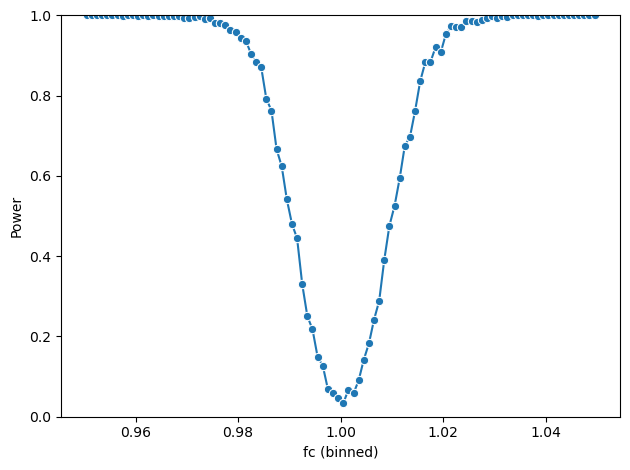

In [55]:
scm.pow_curve(mergy,n_bins=100)

In [38]:
client.close()
cluster.close()